# Customer Care Intent Classifier: Attention-BiLSTM Router

This notebook implements a custom text routing classifier designed to route user queries into one of 27 distinct customer support categories.

### Why this architecture?
1. **BiLSTM**: LSTMs capture temporal dependencies in text. Bidirectional processing ensures context is learned from both left-to-right and right-to-left.
2. **Global Attention**: A custom attention mechanism calculates a weight score for every token's hidden state, allowing the network to focus on the key intent-carrying words rather than sequence length.
3. **ONNX Export**: Once trained, the computational graph is exported to ONNX format to support lightweight, high-throughput inference on CPU.


### 1. Library Imports & Setup
We import core libraries including PyTorch for deep learning, spaCy for tokenization/lemmatization, and PySpellChecker for typo correction. We also verify GPU availability.


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import joblib
import time
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import spacy
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
!pip install pyspellchecker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 58.3 MB/s eta 0:00:0000:0100:01


In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.10.0+cu128
Using device: cuda


### 2. Dataset Loading & Class Mapping
We load the preprocessed corpus. Alphanumeric patterns (like order IDs, currency details) have been mapped to a standard placeholder (`unk_placeholder`) to prevent the model from overfitting on specific numbers.


In [4]:
data = pd.read_csv("/kaggle/input/datasets/akshat14s/customer-support-intent-classification-dataset/cleaned_data_for_training.csv")
data = data.rename(columns={'cleaned_text': 'text'})

In [5]:
data.head()

,text,label
0,question about cancelling order unk_placeholder,0
1,i have a question about cancelling oorder unk_...,0
2,i need help cancelling puchase unk_placeholder,0
3,i need to cancel purchase unk_placeholder,0
4,i cannot afford this order cancel purchase unk...,0


### 3. Training Text Normalization & Autocorrect
Customer queries often contain typos (e.g., 'refnd' instead of 'refund'). We pass the training data through a typo-correction filter using Levenshtein distance, ignoring alphanumeric codes to preserve valid product or transaction IDs.


In [6]:
from spellchecker import SpellChecker

In [ ]:
spell = SpellChecker(distance=1)

def process_training_text(text):
    if not isinstance(text, str):
        return ""
    
    words = text.lower().split()
    corrected_words = []
    
    for word in words:
        if word.isalpha():
            corrected = spell.correction(word)
            corrected_words.append(corrected if corrected is not None else word)
        else:
            corrected_words.append(word)
            
    return " ".join(corrected_words)

print("Initiating dataset spellcheck...")
start_time = time.time()
data['text'] = data['text'].apply(process_training_text)
end_time = time.time()
print(f"Training dataset spellcheck complete in {round(end_time - start_time, 2)} seconds!")

Initiating dataset spellcheck...
Training dataset spellcheck complete in 4.1 seconds!


### 4. Stratified Train-Validation Split
To ensure that all 27 intent classes are equally represented in both splits, we perform a stratified 80/20 train-validation split using `train_test_split` with `stratify=raw_labels`.


In [ ]:
raw_texts = data['text'].astype(str).tolist()
raw_labels = data['label'].tolist()

# Stratified split (80% Train, 20% Val)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    raw_texts, 
    raw_labels, 
    test_size=0.2, 
    random_state=42, 
    stratify=raw_labels
)

In [9]:
print(f"Data split successful!")
print(f"Training sentences: {len(X_train_raw)}")
print(f"Validation sentences: {len(X_val_raw)}")
print(f"Number of unique classes detected: {len(np.unique(y_train))}")

Data split successful!
Training sentences: 21497
Validation sentences: 5375
Number of unique classes detected: 27


### 5. NLP Pipeline: Lemmatization & Custom Vocabulary Mapping
We load the `en_core_web_sm` model from spaCy, disabling the parser and NER components to speed up processing. Words are converted to their lowercased base lemmas to collapse inflectional variations. We then build a vocabulary index, keeping words that appear at least 3 times and reserving indices `0` for `<PAD>` and `1` for `<UNK>`.


In [ ]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

In [ ]:
def clean_and_tokenize(text_list):
    cleaned_tokens = []
    
    for doc in nlp.pipe(text_list, batch_size=512):
        tokens = [token.lemma_.lower() for token in doc if not token.is_punct and not token.is_space]
        cleaned_tokens.append(tokens)
        
    return cleaned_tokens

In [ ]:
print("Processing training text with spaCy... (this may take a minute)")
X_train_tokens = clean_and_tokenize(X_train_raw)

print("Processing validation text with spaCy...")
X_val_tokens = clean_and_tokenize(X_val_raw)

print("Text processing complete!")
print(f"Original: {X_train_raw[0]}")
print(f"Processed: {X_train_tokens[0]}")

Processing training text with spaCy... (this may take a minute)
Processing validation text with spaCy...
Text processing complete!
Original: i want assistance informing of a trouble with payment
Processed: ['i', 'want', 'assistance', 'informing', 'of', 'a', 'trouble', 'with', 'payment']


In [ ]:
all_words = [token for sentence in X_train_tokens for token in sentence]
unique_words_count = len(set(all_words))
total_words_count = len(all_words)

print(f"--- VOCABULARY AUDIT ---")
print(f"Total tokens processed across all text: {total_words_count}")
print(f"Actual unique words found by spaCy: {unique_words_count}")
print("-" * 30)

word_counts = Counter(all_words)
print("Top 15 Most Common Cleaned Words:")
for word, count in word_counts.most_common(15):
    print(f"  - '{word}': {count} times")

print("-" * 30)

rare_words_1 = [word for word, count in word_counts.items() if count == 1]
rare_words_2 = [word for word, count in word_counts.items() if count == 2]

print(f"Words that appear exactly ONCE: {len(rare_words_1)}")
print(f"Words that appear exactly TWICE: {len(rare_words_2)}")

print(f"Sample words appearing only once: {rare_words_1[:10]}")

--- VOCABULARY AUDIT ---
Total tokens processed across all text: 183156
Actual unique words found by spaCy: 852
------------------------------
Top 15 Most Common Cleaned Words:
  - 'i': 18444 times
  - 'to': 13251 times
  - 'do': 5476 times
  - 'help': 5371 times
  - 'the': 5178 times
  - 'unk_placeholder': 5010 times
  - 'a': 4863 times
  - 'can': 4789 times
  - 'my': 3844 times
  - 'how': 3400 times
  - 'need': 3292 times
  - 'of': 3205 times
  - 'account': 3047 times
  - 'not': 2808 times
  - 'want': 2553 times
------------------------------
Words that appear exactly ONCE: 343
Words that appear exactly TWICE: 98
Sample words appearing only once: ['august', 'tochange', 'modalitiesare', 'wannaclose', 'modifythe', 'cab', 'tanya', 'enterthe', 'somearticle', 'fear']


In [ ]:
pristine_words = [word for word, count in word_counts.items() if count >= 3]

word_to_idx = {word: idx + 2 for idx, word in enumerate(pristine_words)}

word_to_idx["<PAD>"] = 0
word_to_idx["<UNK>"] = 1

VOCAB_SIZE = len(word_to_idx)

print(f"Pristine Vocabulary Map Configured!")
print(f"Total Model Vocab Size: {VOCAB_SIZE}")
print(f"Verification - 'account' index: {word_to_idx.get('account')}")
print(f"Verification - 'tfack' (typo) index: {word_to_idx.get('tfack', 1)} (Should be 1 for <UNK>)")

Pristine Vocabulary Map Configured!
Total Model Vocab Size: 413
Verification - 'account' index: 59
Verification - 'tfack' (typo) index: 1 (Should be 1 for <UNK>)


In [15]:
# Calculate the token length of each sentence in the training data
sentence_lengths = [len(tokens) for tokens in X_train_tokens]

print("--- SENTENCE LENGTH ANALYSIS ---")
print(f"Shortest sentence: {min(sentence_lengths)} words")
print(f"Longest sentence: {max(sentence_lengths)} words")
print(f"Average sentence length: {np.mean(sentence_lengths):.1f} words")
print(f"95th percentile length: {np.percentile(sentence_lengths, 95):.0f} words")

--- SENTENCE LENGTH ANALYSIS ---
Shortest sentence: 1 words
Longest sentence: 16 words
Average sentence length: 8.5 words
95th percentile length: 13 words


### 6. Vectorizing & Batching (PyTorch Dataset & DataLoader)
We vectorize the text by converting word tokens to vocabulary indices. We pad or truncate sequences to a fixed window length of 16 tokens and wrap them in a PyTorch `DataLoader` with shuffling for batch-wise gradient updates.


In [ ]:
class IntentDataset(Dataset):
    def __init__(self, tokenized_texts, labels, word_to_idx, max_len=16):
        self.labels = labels
        self.sequences = []
        
        for tokens in tokenized_texts:
            encoded = [word_to_idx.get(token, 1) for token in tokens[:max_len]]
            
            padded = encoded + [0] * (max_len - len(encoded))
            self.sequences.append(padded)
            
        self.X = torch.tensor(self.sequences, dtype=torch.long)
        self.y = torch.tensor(self.labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.y)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
train_dataset = IntentDataset(X_train_tokens, y_train, word_to_idx, max_len=16)
val_dataset = IntentDataset(X_val_tokens, y_val, word_to_idx, max_len=16)

print("PyTorch Dataset objects created successfully!")
sample_X, sample_y = train_dataset[0]
print(f"Sample padded tensor input: {sample_X}")
print(f"Sample tensor label: {sample_y}")

PyTorch Dataset objects created successfully!
Sample padded tensor input: tensor([ 2,  3,  4,  5,  6,  7,  8,  9, 10,  0,  0,  0,  0,  0,  0,  0])
Sample tensor label: 18


In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    drop_last=False
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False
)

print("DataLoaders successfully configured!")
first_batch_X, first_batch_y = next(iter(train_loader))
print(f"Batch X shape: {first_batch_X.shape} (Expected: [64, 16])")
print(f"Batch y shape: {first_batch_y.shape} (Expected: [64])")

DataLoaders successfully configured!
Batch X shape: torch.Size([64, 16]) (Expected: [64, 16])
Batch y shape: torch.Size([64]) (Expected: [64])


### 7. Initializing Pre-trained GloVe Embeddings
Instead of training embeddings from scratch, we initialize our weights with pre-trained 100-dimensional GloVe vectors. Words not in the vocabulary fallback to uniform random initialization, and `<PAD>` is forced to zero.


In [ ]:
import gensim.downloader as api

print("Downloading pre-trained word vectors via Gensim... (this may take a minute)")
glove_vectors = api.load("glove-wiki-gigaword-100")
print("Vectors loaded successfully!")

[==================================================] 100.0% 128.1/128.1MB downloaded
Vectors loaded successfully!


In [ ]:
embedding_dim = 100
embedding_matrix = np.random.uniform(-0.1, 0.1, (VOCAB_SIZE, embedding_dim))

embedding_matrix[0] = np.zeros(embedding_dim)

found_words = 0
for word, idx in word_to_idx.items():
    if idx == 0 or idx == 1:
        continue
        
    if word in glove_vectors:
        embedding_matrix[idx] = glove_vectors[word]
        found_words += 1

PRETRAINED_WEIGHTS = torch.FloatTensor(embedding_matrix)

print("--- EMBEDDING MATRIX REPORT ---")
print(f"Total vocabulary checked: {VOCAB_SIZE - 2}")
print(f"Successfully matched with pre-trained vectors: {found_words}")
print(f"Words fallback to random initialization: {(VOCAB_SIZE - 2) - found_words}")
print(f"Final PyTorch weight matrix shape: {PRETRAINED_WEIGHTS.shape}")

--- EMBEDDING MATRIX REPORT ---
Total vocabulary checked: 411
Successfully matched with pre-trained vectors: 373
Words fallback to random initialization: 38
Final PyTorch weight matrix shape: torch.Size([413, 100])


### 8. Custom Global Attention & BiLSTM Architecture
We define our custom neural network layers:
1. **GlobalAttention**: Learns a linear projection of hidden states, normalizes them via softmax, and performs batch matrix multiplication to return a single context vector.
2. **IntentClassifierLSTM**: Passes word indices through a frozen GloVe embedding layer, runs a bidirectional LSTM, applies the Global Attention layer, and projects output features via a linear classifier head.


In [21]:
class GlobalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(GlobalAttention, self).__init__()
        self.attention_weights = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, lstm_outputs):
        scores = self.attention_weights(lstm_outputs).squeeze(-1)  
        alphas = F.softmax(scores, dim=1)  
        alphas = alphas.unsqueeze(1)  
        context_vector = torch.bmm(alphas, lstm_outputs).squeeze(1)  
        return context_vector

In [ ]:
class IntentClassifierLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, pretrained_weights):
        super(IntentClassifierLSTM, self).__init__()
        
        self.embedding = nn.Embedding.from_pretrained(
            pretrained_weights, 
            freeze=True, 
            padding_idx=0
        )        
        self.lstm = nn.LSTM(
            input_size=embedding_dim, 
            hidden_size=hidden_dim, 
            num_layers=1, 
            batch_first=True, 
            bidirectional=True
        )        
        self.attention = GlobalAttention(hidden_dim * 2)        
        self.dropout = nn.Dropout(p=0.3)        
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        
    def forward(self, text):
        
        embedded = self.embedding(text) 
        lstm_out, (h_n, c_n) = self.lstm(embedded)
        context_vector = self.attention(lstm_out)
        hidden_dropout = self.dropout(context_vector)
        logits = self.fc(hidden_dropout)
        
        return logits

print("Attention-BiLSTM Network Architecture successfully compiled!")

Attention-BiLSTM Network Architecture successfully compiled!


### 9. Optimizer & Loss Setup
We configure the CrossEntropyLoss function and Adam optimizer. The model is sent to GPU memory if available.


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = IntentClassifierLSTM(
    vocab_size=VOCAB_SIZE,
    embedding_dim=100,
    hidden_dim=128,
    output_dim=27,
    pretrained_weights=PRETRAINED_WEIGHTS
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"Model successfully loaded onto: {device}")
print(model)

Model successfully loaded onto: cuda
IntentClassifierLSTM(
  (embedding): Embedding(413, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (attention): GlobalAttention(
    (attention_weights): Linear(in_features=256, out_features=1, bias=False)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=27, bias=True)
)


### 10. Training Loop Functions
We define epoch operations for training and validation. To stabilize LSTM training, gradient clipping (`clip_grad_norm_`) is applied to prevent gradient explosion.


In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_predictions += (predicted == y_batch).sum().item()
        total_samples += y_batch.size(0)
        
    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    return epoch_loss, epoch_acc

print("Training step function successfully defined!")

Training step function successfully defined!


In [ ]:
def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == y_batch).sum().item()
            total_samples += y_batch.size(0)
            
    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    return epoch_loss, epoch_acc

print("Validation function successfully defined!")

Validation function successfully defined!


### 11. Model Training
We train our Attention-BiLSTM classifier for 15 epochs, tracking the loss and accuracy metrics for both splits.


In [ ]:
EPOCHS = 15

print("Starting training loop...")
print("-" * 50)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f"Epoch {epoch+1:02d}/{EPOCHS:02d} | "
          f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc*100:.2f}%")

print("-" * 50)
print("Training complete!")

Starting training loop...
--------------------------------------------------
Epoch 01/15 | Train Loss: 0.9405 - Train Acc: 77.33% | Val Loss: 0.0939 - Val Acc: 98.08%
Epoch 02/15 | Train Loss: 0.0582 - Train Acc: 98.83% | Val Loss: 0.0344 - Val Acc: 99.29%
Epoch 03/15 | Train Loss: 0.0277 - Train Acc: 99.39% | Val Loss: 0.0317 - Val Acc: 99.24%
Epoch 04/15 | Train Loss: 0.0182 - Train Acc: 99.59% | Val Loss: 0.0241 - Val Acc: 99.44%
Epoch 05/15 | Train Loss: 0.0157 - Train Acc: 99.60% | Val Loss: 0.0277 - Val Acc: 99.20%
Epoch 06/15 | Train Loss: 0.0111 - Train Acc: 99.77% | Val Loss: 0.0190 - Val Acc: 99.52%
Epoch 07/15 | Train Loss: 0.0091 - Train Acc: 99.78% | Val Loss: 0.0201 - Val Acc: 99.46%
Epoch 08/15 | Train Loss: 0.0079 - Train Acc: 99.81% | Val Loss: 0.0169 - Val Acc: 99.40%
Epoch 09/15 | Train Loss: 0.0061 - Train Acc: 99.86% | Val Loss: 0.0171 - Val Acc: 99.52%
Epoch 10/15 | Train Loss: 0.0060 - Train Acc: 99.86% | Val Loss: 0.0173 - Val Acc: 99.40%
Epoch 11/15 | Train Los

### 12. Classification Performance Evaluation
We evaluate our model's performance on the validation set, printing a precision, recall, and F1-score report across the 27 intent classes.


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       200
           1       0.99      1.00      0.99       199
           2       0.99      1.00      1.00       195
           3       1.00      1.00      1.00       190
           4       0.99      0.99      0.99       200
           5       1.00      1.00      1.00       200
           6       1.00      0.99      0.99       199
           7       1.00      1.00      1.00       200
           8       1.00      0.99      0.99       200
           9       0.99      0.99      0.99       200
          10       0.99      0.99      0.99       199
          11       0.99      0.99      0.99       199
          12       1.00      1.00      1.00       199
          13       1.00      1.00      1.00       200
          14       1.00      1.00      1.00       200
          15       0.99      0.98      0.99       200
          16       0.97      1.00      0.99       1

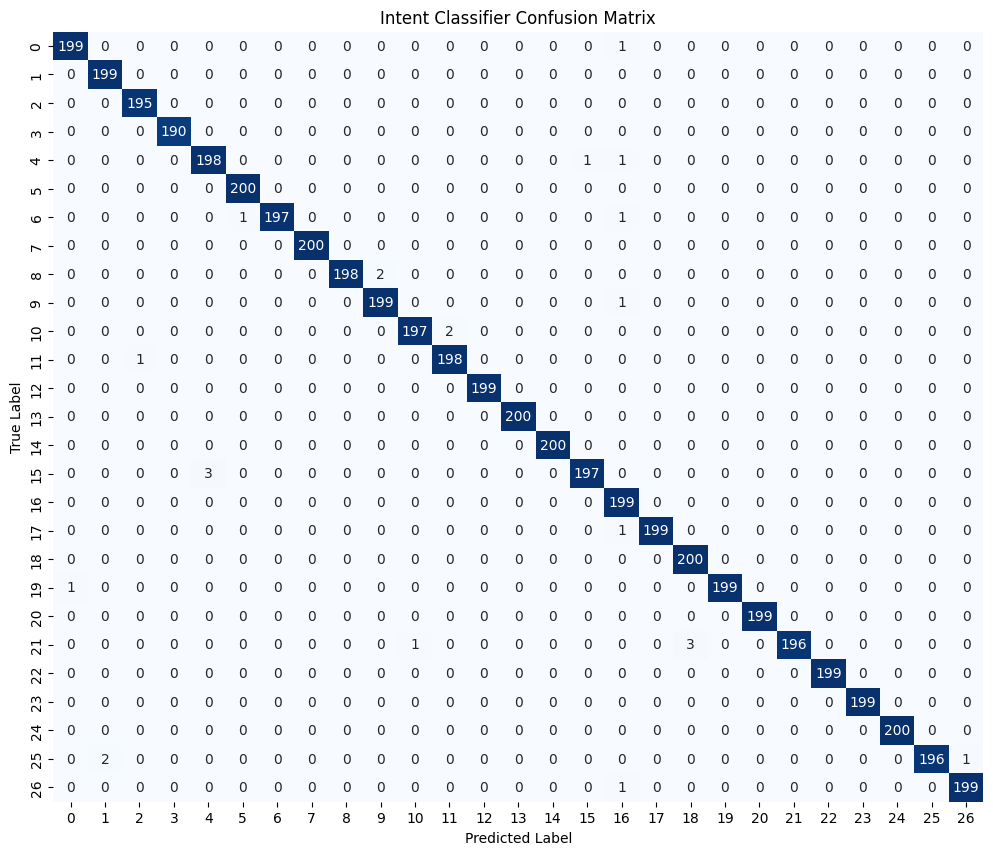

In [ ]:
all_preds = []
all_trues = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_trues.extend(y_batch.numpy())

print("--- CLASSIFICATION REPORT ---")
print(classification_report(all_trues, all_preds))

plt.figure(figsize=(12, 10))
cm = confusion_matrix(all_trues, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Intent Classifier Confusion Matrix')
plt.show()

### 13. Model Export (ONNX Format)
To ensure lightweight, platform-independent deployment on CPU, we export our trained PyTorch model to the ONNX format. The vocabulary mapping dictionary is saved using `joblib` with compression.


In [28]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 10.7 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 13.3 MB/s eta 0:00:00


In [ ]:
MODEL_SAVE_PATH = 'intent_classifier_lstm_model.onnx'
VOCAB_SAVE_PATH = 'vocab_map.joblib'

model.eval()
device = next(model.parameters()).device
dummy_input = torch.zeros((1, 16), dtype=torch.long).to(device)

torch.onnx.export(
    model, 
    dummy_input, 
    MODEL_SAVE_PATH, 
    export_params=True,        
    opset_version=12,          
    input_names=['input'],     
    output_names=['output'],   
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)

joblib.dump(word_to_idx, VOCAB_SAVE_PATH, compress=3)

print(f"Saved model to: {MODEL_SAVE_PATH}")
print(f"Saved compressed vocabulary dictionary to: {VOCAB_SAVE_PATH}")

/tmp/ipykernel_58/1777758279.py:11: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0707 11:25:43.724000 58 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `IntentClassifierLSTM([...]` with `torch.export.export(..., strict=False)`...


/usr/lib/python3.12/contextlib.py:158: UserWarning: The tensor attributes self.lstm._flat_weights[0], self.lstm._flat_weights[1], self.lstm._flat_weights[2], self.lstm._flat_weights[3], self.lstm._flat_weights[4], self.lstm._flat_weights[5], self.lstm._flat_weights[6], self.lstm._flat_weights[7] were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  self.gen.throw(value)


[torch.onnx] Obtain model graph for `IntentClassifierLSTM([...]` with `torch.export.export(..., strict=False)`... ❌
[torch.onnx] Obtain model graph for `IntentClassifierLSTM([...]` with `torch.export.export(..., strict=True)`...
[torch.onnx] Obtain model graph for `IntentClassifierLSTM([...]` with `torch.export.export(..., strict=True)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Saved model to: intent_classifier_lstm_model.onnx
Saved compressed vocabulary dictionary to: vocab_map.joblib


### 14. Inference Pipeline & Live Autocorrect Test
We define the end-to-end prediction pipeline and run stress tests with noisy, typo-ridden customer queries to evaluate the router's robustness in real-time settings.


In [ ]:
def predict_intent(raw_text, model, word_to_idx, max_len=16):
    model.eval() 
    
    doc = nlp(raw_text)
    tokens = [token.lemma_.lower() for token in doc if not token.is_punct and not token.is_space]
    encoded = [word_to_idx.get(token, 1) for token in tokens[:max_len]]
    padded = encoded + [0] * (max_len - len(encoded))
    input_tensor = torch.tensor(padded, dtype=torch.long).unsqueeze(0)
    device = next(model.parameters()).device
    input_tensor = input_tensor.to(device)
    
    with torch.no_grad():
        logits = model(input_tensor)
        predicted_class = torch.argmax(logits, dim=1).item()
        
    return predicted_class

print("Inference function successfully loaded into active memory!")

Inference function successfully loaded into active memory!


In [ ]:
# A simple list of test sentences to check model response
test_queries = [
    "i want to close my account immediately",
    "can i get a refund for my last transaction",
    "how do i change my login password",
    "i am trying to track my shipped package order",
    "is there an annual fee for using this application",
    "please terminate my user profile right now",
    "my money went through but i never received the digital items",
    "i cannot seem to log back in because it says wrong credentials",
    "where is my delivery it was supposed to arrive yesterday",
    "are there hidden charges on my monthly subscription bill",
    "hello customer service department i am writing this long message because i urgently need to delete my account due to personal reasons",
    "hey could you please look up my transaction history and initiate a complete money refund back to my original bank account right now",
    "i need to cancel my subscrie immediately tfack",          
    "my paidx transaction went wrong please give me a refund",
    "help me recover my passwrd i lost access to my security", 
    "cn u refnd my cash for last deal plss",                  
    "i want to delet my profile permanntly from this site",    
    "how to track orderr status showing delivery delayy",     
    "accnt recovery not working reset link broken help",     
    "is there extra chargees or transction fees on international payment"
]

print("--- LIVE INFERENCE TEST ---")
for query in test_queries:
    predicted_class_idx = predict_intent(query, model, word_to_idx, max_len=16)
    print(f"Query: '{query}' -> Predicted Class Index: {predicted_class_idx}")

--- LIVE INFERENCE TEST ---
Query: 'i want to close my account immediately' -> Predicted Class Index: 11
Query: 'can i get a refund for my last transaction' -> Predicted Class Index: 16
Query: 'how do i change my login password' -> Predicted Class Index: 20
Query: 'i am trying to track my shipped package order' -> Predicted Class Index: 25
Query: 'is there an annual fee for using this application' -> Predicted Class Index: 5
Query: 'please terminate my user profile right now' -> Predicted Class Index: 20
Query: 'my money went through but i never received the digital items' -> Predicted Class Index: 19
Query: 'i cannot seem to log back in because it says wrong credentials' -> Predicted Class Index: 15
Query: 'where is my delivery it was supposed to arrive yesterday' -> Predicted Class Index: 13
Query: 'are there hidden charges on my monthly subscription bill' -> Predicted Class Index: 4
Query: 'hello customer service department i am writing this long message because i urgently need to d

In [ ]:
spell = SpellChecker()

def lean_autocorrect(text: str) -> str:
    text = text.lower()
    words = text.split()
    corrected_words = []
    for word in words:
        corrected = spell.correction(word)
        if corrected is not None:
            corrected_words.append(corrected)
        else:
            corrected_words.append(word)
    return " ".join(corrected_words)

mapping_path = '/kaggle/input/datasets/akshat14s/customer-support-intent-classification-dataset/label_mapping.json'
with open(mapping_path, 'r') as f:
    raw_mapping = json.load(f)
    
class_map = {int(k): v for k, v in raw_mapping.items()}

print("--- LIVE INFERENCE TEST WITH INTENT NAMES (PYSPELLCHECKER ACTIVE) ---")
for query in test_queries:
    corrected_query = lean_autocorrect(query)
    
    predicted_class_idx = predict_intent(corrected_query, model, word_to_idx, max_len=16)
    
    intent_name = class_map.get(predicted_class_idx, f"Unknown (Index {predicted_class_idx})")
    
    print(f"Query: '{query}'")
    if query.lower() != corrected_query.lower():
        print(f" -> Spell Corrected: '{corrected_query}'")
    print(f" -> Intent: {intent_name}\n")

--- LIVE INFERENCE TEST WITH INTENT NAMES (PYSPELLCHECKER ACTIVE) ---
Query: 'i want to close my account immediately'
 -> Intent: delete_account

Query: 'can i get a refund for my last transaction'
 -> Intent: get_refund

Query: 'how do i change my login password'
 -> Intent: recover_password

Query: 'i am trying to track my shipped package order'
 -> Intent: track_order

Query: 'is there an annual fee for using this application'
 -> Intent: check_payment_methods

Query: 'please terminate my user profile right now'
 -> Intent: recover_password

Query: 'my money went through but i never received the digital items'
 -> Intent: place_order

Query: 'i cannot seem to log back in because it says wrong credentials'
 -> Intent: get_invoice

Query: 'where is my delivery it was supposed to arrive yesterday'
 -> Intent: delivery_period

Query: 'are there hidden charges on my monthly subscription bill'
 -> Intent: check_invoice

Query: 'hello customer service department i am writing this long mess